In [45]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Optimize JupyterLab display aesthetics

In [46]:
pl.Config.set_tbl_rows(15)
pl.Config.set_tbl_cols(12)
pl.Config.set_float_precision(4)

polars.config.Config

# 2. Open an un-materialized high-performance file stream pointer

In [47]:
# Starts directly in your current notebook directory
data_dir = Path.cwd() / "data/1_rawdata" if (Path.cwd() / "data").exists() else Path.cwd().parent / "data/1_rawdata"

# Combine paths cleanly
csv_path = data_dir / "utility_provider.csv"

print(csv_path)

df = pl.read_csv(
    csv_path,
    has_header=True,
    separator=",",
    
    # Performance & Memory Tuning
    infer_schema_length=10000,  # Look at 10k rows to accurately detect data types
    n_rows=None,                # Set to an integer (e.g., 10000) to test a small subset first
    
    # Data Cleaning & Safety
    ignore_errors=False,        # Set to True to drop malformed/corrupted rows instead of crashing
    try_parse_dates=True        # Automatically convert date/time columns to Polars Date/Datetime types
)

/workspace/data/1_rawdata/utility_provider.csv


# 3. Data Profiling

In [48]:
# 3.1.  Utility Provider Schema
print("--- Utility Provider Data Schema Preview ---")
print(df.schema)

--- Utility Provider Data Schema Preview ---
Schema([('Provider ID', String), ('Name', String), ('Region', String)])


In [49]:
# 3,2.  Utility Provider Data Shape & Describe Preview
print("--- Utility Provider Data Shape and Describe Preview ---")
print(df.glimpse())


--- Utility Provider Data Shape and Describe Preview ---
Rows: 5
Columns: 3
$ Provider ID <str> 'UP-001', 'UP-002', 'UP-003', 'UP-004', 'UP-005'
$ Name        <str> 'Andes Power Co', 'Pacifica Energy', 'Northern Grid Utilities', 'Meridian Electric', 'Southern Cross Power'
$ Region      <str> 'North', 'South', 'East', 'West', 'Central'

None


# 4. Count missing values in parallel across millions of records

In [50]:
# Create a comprehensive audit summary
total_rows = df.height
null_counts = df.select(pl.all().is_null().sum())
null_pcts = df.select((pl.all().is_null().sum() / total_rows * 100).round(2))

# Reshape them vertically using unpivot
counts_vertical = null_counts.unpivot(variable_name="Column", value_name="Null Count")
pcts_vertical = null_pcts.unpivot(variable_name="Column", value_name="Null Percentage (%)")

# Join them together by the Column name
audit_df = counts_vertical.join(pcts_vertical, on="Column").sort("Null Count", descending=True)

print(audit_df)

shape: (3, 3)
┌─────────────┬────────────┬─────────────────────┐
│ Column      ┆ Null Count ┆ Null Percentage (%) │
│ ---         ┆ ---        ┆ ---                 │
│ str         ┆ u32        ┆ f64                 │
╞═════════════╪════════════╪═════════════════════╡
│ Provider ID ┆ 0          ┆ 0.0000              │
│ Name        ┆ 0          ┆ 0.0000              │
│ Region      ┆ 0          ┆ 0.0000              │
└─────────────┴────────────┴─────────────────────┘


# 5 Plotting chart about metrics generated from the exploration.

In [51]:
# 5.1.. Calculate the metrics
total_rows = df.height

# Count actual Polars 'null' values across all columns
total_nulls = df.select(pl.all().is_null().sum()).sum_horizontal().item()


# Count empty strings ("") which often represent missing text data
string_cols = [col for col, dtype in df.schema.items() if dtype == pl.String]
if string_cols:
    total_empty_strings = df.select(pl.col(string_cols).eq("").sum()).sum_horizontal().item()
else:
    total_empty_strings = 0


In [52]:
# 5.2.. Setup data for plotting
metrics = ['Total Rows', 'Null Values', 'Missing (Empty Strings)']
counts = [total_rows, total_nulls, total_empty_strings]
colors = ['#1f77b4', '#ff7f0e', '#d62728'] # Blue, Orange, Red

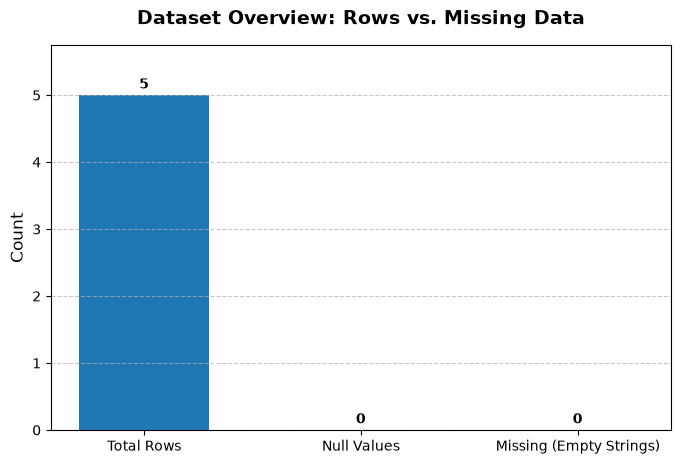

In [53]:
# 5.3. Generate the plot
plt.figure(figsize=(8, 5))
bars = plt.bar(metrics, counts, color=colors, width=0.6)

# Add exact value labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (total_rows * 0.01), 
             f'{yval:,}', ha='center', va='bottom', fontweight='bold')

plt.title('Dataset Overview: Rows vs. Missing Data', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust y-limit to give space for labels
plt.ylim(0, max(counts) * 1.15)

plt.show()